# Economic Significance V6 - DCA cu Pauza V5
**Investitor A (DCA Pur):** $100/saptamana mereu in SP500, indiferent de piata

**Investitor B (DCA V5 Pause):** $100/saptamana normal. Cand SP500 cade >10% fata de maxim,
opreste DCA si acumuleaza cash. Cand V5 confirma V-shape, deploye tot cash-ul si reia DCA.

**Metrica principala:** Unitati SP500 acumulate dupa acelasi capital total investit

**Perioada:** Ianuarie 2017 - Aprilie 2026 (9 ani, complet out-of-sample)

## 1. Import si Incarcare Model

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, pickle, os, warnings
warnings.filterwarnings('ignore')
from fredapi import Fred

os.makedirs('plots', exist_ok=True)
os.makedirs('data',  exist_ok=True)

ensemble = pickle.load(open('../V5/models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('../V5/models/v5_scaler.pkl',   'rb'))

with open('../V5/models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']
OPTIMAL_THRESHOLD = meta['optimal_threshold']
WEEKLY_BUDGET     = 100     # $100/saptamana
TRIGGER_DROP      = 0.10    # pauza cand SP500 cade 10% fata de maxim
LOOKBACK_WEEKS    = 20      # fereastra pentru calculul maximului recent

print('Model:', meta['model_name'], '| AUC:', meta['auc'])
print('Threshold V5:', OPTIMAL_THRESHOLD)
print('Budget:', WEEKLY_BUDGET, '$/saptamana')
print('Trigger pauza:', str(int(TRIGGER_DROP*100)) + '% cadere fata de maxim', LOOKBACK_WEEKS, 'saptamani')

Model: Voting Ensemble | AUC: 0.804
Threshold V5: 0.62
Budget: 100 $/saptamana
Trigger pauza: 10% cadere fata de maxim 20 saptamani


## 2. FRED API Key

In [2]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'
fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Descarcare Date

In [3]:
START_DATA     = '2016-01-01'
START_BACKTEST = '2017-01-01'
END_BACKTEST   = '2026-04-14'

sp500 = yf.download('^GSPC', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATA, end=END_BACKTEST, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

FALLBACK_VALUES = {
    'Yield_Curve': 0.50, 'Jobless_Claims': 300000,
    'Credit_Spread': 3.50, 'Dollar_Index': 90.0, 'Fed_Rate': 2.50
}
fred_series = {
    'Yield_Curve'   : ['T10Y2Y', 'T10Y3M', 'DGS10'],
    'Jobless_Claims': ['ICSA', 'IC4WSA'],
    'Credit_Spread' : ['BAMLH0A0HYM2', 'BAMLC0A0CBBB'],
    'Dollar_Index'  : ['DTWEXM', 'DTWEXBGS'],
    'Fed_Rate'      : ['FEDFUNDS', 'DFF', 'DFEDTARU']
}

macro_raw = pd.DataFrame()
for name, codes in fred_series.items():
    success = False
    for code in codes:
        try:
            series = fred.get_series(code, observation_start=START_DATA, observation_end=END_BACKTEST)
            if series.dropna().empty:
                continue
            series.name = name
            macro_raw = macro_raw.join(series, how='outer') if not macro_raw.empty else series.to_frame()
            print(name.ljust(20), '| OK:', code, '| Ultima val:', round(series.dropna().iloc[-1], 3))
            success = True
            break
        except:
            continue
    if not success:
        macro_raw[name] = FALLBACK_VALUES.get(name, 0.0)
        print(name.ljust(20), '| FALLBACK')

macro_raw.index = pd.to_datetime(macro_raw.index)
macro_raw = macro_raw.ffill().bfill()
print('Date descarcate.')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Yield_Curve          | OK: T10Y2Y | Ultima val: 0.52
Jobless_Claims       | OK: ICSA | Ultima val: 219000.0
Credit_Spread        | OK: BAMLH0A0HYM2 | Ultima val: 2.95
Dollar_Index         | OK: DTWEXM | Ultima val: 90.822
Fed_Rate             | OK: FEDFUNDS | Ultima val: 3.64
Date descarcate.


## 4. Feature Engineering + Semnal V5

In [4]:
df = daily.join(macro_raw, how='left').ffill().bfill()

df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

delta = df['SP500_Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals, x = series.values, np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']      = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d']    = rolling_slope(df['SP500_Close'], 20)
df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']
df['Dollar_Change']      = df['Dollar_Index'].pct_change(4).fillna(0.0)

agg_rules = {
    'SP500_Close': 'last', 'SP500_Volume': 'sum', 'VIX_raw': 'mean',
    'Dist_MA50': 'last', 'Dist_MA200': 'last', 'Dist_52w_High': 'last',
    'RSI': 'last', 'Dist_Local_Min': 'last', 'VIX_Ratio': 'mean',
    'VIX_Trend_20d': 'mean', 'SP500_Trend_20d': 'last',
    'Realized_Vol_10d': 'mean', 'Yield_Curve': 'mean',
    'Yield_Curve_Change': 'last', 'Jobless_Ratio': 'mean', 'Dollar_Change': 'last'
}
for col in ['Credit_Spread', 'Fed_Rate']:
    if col in df.columns:
        agg_rules[col] = 'mean' if col == 'Credit_Spread' else 'last'

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly = weekly.loc[:, ~weekly.columns.duplicated()]
for col, val in [('Credit_Spread', 3.50), ('Fed_Rate', 2.50)]:
    if col not in weekly.columns:
        weekly[col] = val
weekly = weekly.ffill()
weekly.dropna(subset=['Return_1w'], inplace=True)

weekly_bt = weekly[weekly.index >= START_BACKTEST].copy()
weekly_bt['Phase'] = 1

# Drawdown fata de maximul din ultimele LOOKBACK_WEEKS saptamani
weekly_bt['Recent_Max'] = weekly_bt['SP500_Close'].rolling(LOOKBACK_WEEKS).max()
weekly_bt['Drawdown']   = (weekly_bt['SP500_Close'] - weekly_bt['Recent_Max']) / weekly_bt['Recent_Max']

# Semnal V5
X_bt = pd.DataFrame(
    np.zeros((len(weekly_bt), len(FEATURE_COLS))),
    columns=FEATURE_COLS, index=weekly_bt.index
)
for col in FEATURE_COLS:
    if col in weekly_bt.columns:
        X_bt[col] = weekly_bt[col].fillna(0.0).values

proba    = ensemble.predict_proba(scaler.transform(X_bt.values))[:, 1]
proba_s  = pd.Series(proba, index=weekly_bt.index).shift(1).fillna(0)
signal_s = (proba_s >= OPTIMAL_THRESHOLD).astype(int)

weekly_bt['P_VShape'] = proba_s
weekly_bt['Signal']   = signal_s

tbill_w = (weekly_bt.get('Fed_Rate', pd.Series(2.5, index=weekly_bt.index)) / 100 / 52).values

print('Saptamani backtest:', len(weekly_bt))
print('Saptamani in crisis (drawdown > 10%):', (weekly_bt['Drawdown'] <= -TRIGGER_DROP).sum())
print('Saptamani semnal V5:', signal_s.sum())

Saptamani backtest: 485
Saptamani in crisis (drawdown > 10%): 47
Saptamani semnal V5: 34


## 5. Simulare DCA cu Pauza V5

**Logica Investitor B:**
- Saptamani normale (drawdown < 10%): cumpara $100 in SP500
- Saptamani criza (drawdown >= 10%) + Non-V signal: pauza, acumuleaza $100 in cash
- Prima saptamana cu V5 signal dupa criza: deploye $100 + tot cash-ul, reia DCA normal

**Stare:** normal | in_pause | resumed

In [8]:
prices   = weekly_bt['SP500_Close'].values
drawdown = weekly_bt['Drawdown'].values
signals  = signal_s.values
probas   = proba_s.values
n_weeks  = len(weekly_bt)

# --- Investitor A: DCA Pur ---
A_shares, A_total = 0.0, 0.0
A_shares_log, A_value_log = [], []

for i in range(n_weeks):
    px = float(prices[i])
    if px > 0:
        A_shares += WEEKLY_BUDGET / px
        A_total  += WEEKLY_BUDGET
    A_shares_log.append(A_shares)
    A_value_log.append(A_shares * px)

# --- Investitor B: DCA cu Pauza V5 ---
B_shares      = 0.0
B_cash        = 0.0
B_total       = 0.0
B_in_pause    = False
B_shares_log  = []
B_value_log   = []
B_cash_log    = []
B_state_log   = []   # 'normal', 'pause', 'deploy'

RESUME_THRESHOLD = -0.05  # iese din pauza daca drawdown revine > -5%

for i in range(n_weeks):
    px  = float(prices[i])
    dd  = float(drawdown[i]) if not np.isnan(drawdown[i]) else 0.0
    sig = int(signals[i])
    state = 'normal'

    if px <= 0:
        B_shares_log.append(B_shares)
        B_value_log.append(B_shares * px + B_cash)
        B_cash_log.append(B_cash)
        B_state_log.append('normal')
        continue

    if not B_in_pause:
        if dd <= -TRIGGER_DROP:
            # Intra in pauza
            B_in_pause = True
            B_cash    += WEEKLY_BUDGET
            B_cash    *= (1 + tbill_w[i])
            B_total   += WEEKLY_BUDGET
            state      = 'pause'
        else:
            # Normal: cumpara
            B_shares  += WEEKLY_BUDGET / px
            B_total   += WEEKLY_BUDGET
            state      = 'normal'
    else:
        if sig == 1:
            # Semnal V5: deploye tot cash-ul + $100 curent
            amount     = B_cash + WEEKLY_BUDGET
            B_shares  += amount / px
            B_cash     = 0.0
            B_total   += WEEKLY_BUDGET
            B_in_pause = False
            state      = 'deploy'
        elif dd > RESUME_THRESHOLD:
            # Piata s-a recuperat fara semnal V5: deploye cash si reia DCA
            amount     = B_cash + WEEKLY_BUDGET
            B_shares  += amount / px
            B_cash     = 0.0
            B_total   += WEEKLY_BUDGET
            B_in_pause = False
            state      = 'deploy'
        else:
            # Continua pauza
            B_cash    += WEEKLY_BUDGET
            B_cash    *= (1 + tbill_w[i])
            B_total   += WEEKLY_BUDGET
            state      = 'pause'

    B_shares_log.append(B_shares)
    B_value_log.append(B_shares * px + B_cash)
    B_cash_log.append(B_cash)
    B_state_log.append(state)

# DataFrames
idx   = weekly_bt.index
A_df  = pd.DataFrame({'Shares': A_shares_log, 'Value': A_value_log,
                      'Total_Invested': [WEEKLY_BUDGET*(i+1) for i in range(n_weeks)]}, index=idx)
B_df  = pd.DataFrame({'Shares': B_shares_log, 'Value': B_value_log,
                      'Cash': B_cash_log, 'State': B_state_log,
                      'Total_Invested': [WEEKLY_BUDGET*(i+1) for i in range(n_weeks)]}, index=idx)

print('VERIFICARE CAPITAL TOTAL:')
print('  Investitor A: $' + str(round(A_total, 2)))
print('  Investitor B: $' + str(round(B_total, 2)))
print('  Cash ramas B: $' + str(round(B_cash, 2)))
print()
print('Saptamani normale B:  ', B_df[B_df['State']=='normal'].shape[0])
print('Saptamani pauza B:    ', B_df[B_df['State']=='pause'].shape[0])
print('Saptamani deploy B:   ', B_df[B_df['State']=='deploy'].shape[0])
print()

A_shares_final = A_df['Shares'].iloc[-1]
B_shares_final = B_df['Shares'].iloc[-1]
current_price  = float(prices[-1])

A_avg_cost = A_total / A_shares_final
B_invested_in_shares = B_total - B_cash
B_avg_cost = B_invested_in_shares / B_shares_final if B_shares_final > 0 else 0

print('REZULTATE FINALE:')
print('  Investitor A - Shares:', round(A_shares_final, 4),
      '| Valoare: $' + str(round(A_df["Value"].iloc[-1], 2)),
      '| Cost mediu: $' + str(round(A_avg_cost, 2)))
print('  Investitor B - Shares:', round(B_shares_final, 4),
      '| Valoare: $' + str(round(B_df["Value"].iloc[-1], 2)),
      '| Cost mediu: $' + str(round(B_avg_cost, 2)))
print()
delta_shares = round(B_shares_final - A_shares_final, 4)
delta_cost   = round(A_avg_cost - B_avg_cost, 2)
delta_val    = round(B_df["Value"].iloc[-1] - A_df["Value"].iloc[-1], 2)
sign_s = '+' if delta_shares >= 0 else ''
sign_c = '+' if delta_cost >= 0 else ''
sign_v = '+$' if delta_val >= 0 else '-$'
print('  Delta Shares:     ' + sign_s + str(delta_shares))
print('  Delta Cost/Share: ' + sign_c + '$' + str(delta_cost))
print('  Delta Valoare:    ' + sign_v + str(abs(delta_val)))

VERIFICARE CAPITAL TOTAL:
  Investitor A: $48500.0
  Investitor B: $48500.0
  Cash ramas B: $0.0

Saptamani normale B:   410
Saptamani pauza B:     57
Saptamani deploy B:    18

REZULTATE FINALE:
  Investitor A - Shares: 13.226 | Valoare: $91077.09 | Cost mediu: $3667.03
  Investitor B - Shares: 13.1767 | Valoare: $90737.84 | Cost mediu: $3680.74

  Delta Shares:     -0.0493
  Delta Cost/Share: $-13.71
  Delta Valoare:    -$339.25


## 6. Analiza per Episod de Criza

In [9]:
# Identificam episoadele de pauza
B_df['in_pause'] = B_df['State'].isin(['pause', 'deploy'])
episodes = []
in_ep    = False
ep_start = None

for date, row in B_df.iterrows():
    if row['State'] == 'pause' and not in_ep:
        in_ep    = True
        ep_start = date
    elif row['State'] == 'deploy' and in_ep:
        episodes.append({'start': ep_start, 'deploy': date,
                         'deploy_price': float(weekly_bt.loc[date, 'SP500_Close'])})
        in_ep = False
    elif row['State'] == 'normal' and in_ep:
        in_ep = False

# Altern: episoade incomplete (inca in pauza)
if in_ep:
    episodes.append({'start': ep_start, 'deploy': None, 'deploy_price': None})

print('EPISOADE DE PAUZA IDENTIFICATE:', len(episodes))
print()
for ep in episodes:
    start  = ep['start']
    deploy = ep['deploy']
    mask_ep = (B_df.index >= start) & (B_df.index <= (deploy if deploy else B_df.index[-1]))
    weeks_paused  = mask_ep.sum()
    cash_at_deploy = B_df.loc[deploy, 'Cash'] if deploy else B_df['Cash'].iloc[-1]
    price_at_start  = float(weekly_bt.loc[start, 'SP500_Close'])
    price_at_deploy = ep['deploy_price'] if ep['deploy_price'] else float(prices[-1])

    dd_at_start = float(weekly_bt.loc[start, 'Drawdown']) * 100

    print('Episod', ep['start'].strftime('%Y-%m'))
    print('  Inceput pauza:   ', start.date(), '| SP500: $' + str(round(price_at_start, 2)),
          '| Drawdown:', str(round(dd_at_start, 1)) + '%')
    if deploy:
        pct_diff = round((price_at_start - price_at_deploy) / price_at_start * 100, 2)
        print('  Deploy (V5):     ', deploy.date(), '| SP500: $' + str(round(price_at_deploy, 2)),
              '| Diff vs start:', str(pct_diff) + '%')
    else:
        print('  Deploy:           Inca in pauza la sfarsitul perioadei')
    print('  Saptamani pauza: ', weeks_paused)
    print()

EPISOADE DE PAUZA IDENTIFICATE: 18

Episod 2018-11
  Inceput pauza:    2018-11-23 | SP500: $2632.56 | Drawdown: -10.1%
  Deploy (V5):      2019-02-15 | SP500: $2775.6 | Diff vs start: -5.43%
  Saptamani pauza:  13

Episod 2020-02
  Inceput pauza:    2020-02-28 | SP500: $2954.22 | Drawdown: -12.6%
  Deploy (V5):      2020-03-06 | SP500: $2972.37 | Diff vs start: -0.61%
  Saptamani pauza:  2

Episod 2020-03
  Inceput pauza:    2020-03-13 | SP500: $2711.02 | Drawdown: -19.8%
  Deploy (V5):      2020-03-20 | SP500: $2304.92 | Diff vs start: 14.98%
  Saptamani pauza:  2

Episod 2020-03
  Inceput pauza:    2020-03-27 | SP500: $2541.47 | Drawdown: -24.8%
  Deploy (V5):      2020-04-03 | SP500: $2488.65 | Diff vs start: 2.08%
  Saptamani pauza:  2

Episod 2020-04
  Inceput pauza:    2020-04-10 | SP500: $2789.82 | Drawdown: -17.5%
  Deploy (V5):      2020-04-17 | SP500: $2874.56 | Diff vs start: -3.04%
  Saptamani pauza:  2

Episod 2020-04
  Inceput pauza:    2020-04-24 | SP500: $2836.74 | Draw

## 7. Grafic Principal

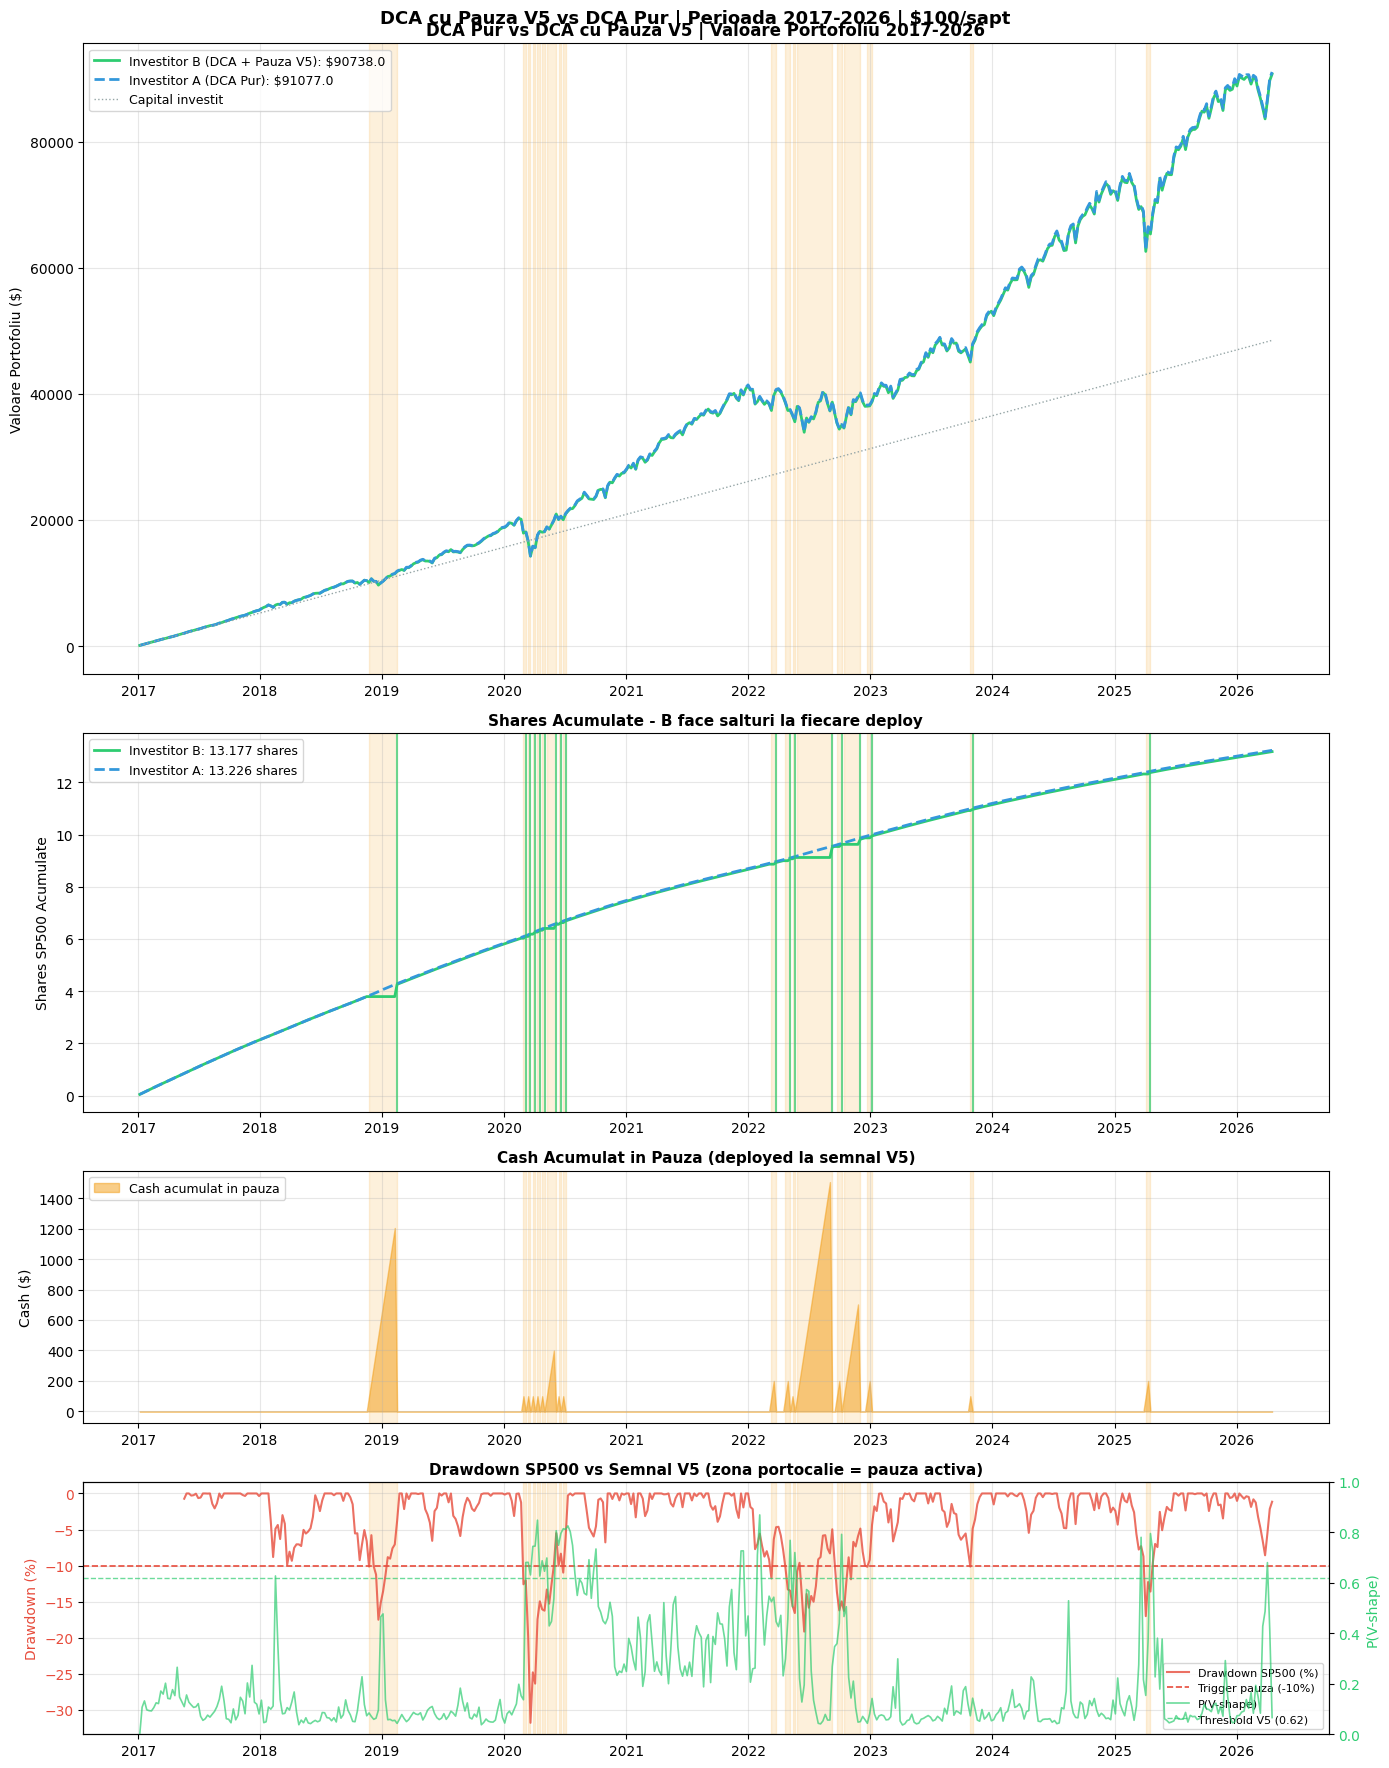

Salvat: plots/economic_v6_dca_pause.png


In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 18),
                         gridspec_kw={'height_ratios': [2.5, 1.5, 1, 1]})

# --- Plot 1: Valoare Portofoliu ---
ax1 = axes[0]
ax1.plot(B_df.index, B_df['Value'], color='#2ecc71', linewidth=2,
         label='Investitor B (DCA + Pauza V5): $' + str(round(B_df["Value"].iloc[-1], 0)))
ax1.plot(A_df.index, A_df['Value'], color='#3498db', linewidth=2, linestyle='--',
         label='Investitor A (DCA Pur): $' + str(round(A_df["Value"].iloc[-1], 0)))
ax1.plot(A_df.index, A_df['Total_Invested'], color='#95a5a6', linewidth=1,
         linestyle=':', label='Capital investit')

# Marcam episoadele de pauza
for ep in episodes:
    end_ep = ep['deploy'] if ep['deploy'] else B_df.index[-1]
    ax1.axvspan(ep['start'], end_ep, alpha=0.15, color='#f39c12', label='_nolegend_')

ax1.set_ylabel('Valoare Portofoliu ($)')
ax1.set_title('DCA Pur vs DCA cu Pauza V5 | Valoare Portofoliu 2017-2026',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Shares Acumulate ---
ax2 = axes[1]
ax2.plot(B_df.index, B_df['Shares'], color='#2ecc71', linewidth=2,
         label='Investitor B: ' + str(round(B_shares_final, 3)) + ' shares')
ax2.plot(A_df.index, A_df['Shares'], color='#3498db', linewidth=2, linestyle='--',
         label='Investitor A: ' + str(round(A_shares_final, 3)) + ' shares')

for ep in episodes:
    end_ep = ep['deploy'] if ep['deploy'] else B_df.index[-1]
    ax2.axvspan(ep['start'], end_ep, alpha=0.15, color='#f39c12')

# Deploy events: salturi brusca in shares
for ep in episodes:
    if ep['deploy']:
        ax2.axvline(ep['deploy'], color='#2ecc71', linewidth=1.5,
                    linestyle='-', alpha=0.7)

ax2.set_ylabel('Shares SP500 Acumulate')
ax2.set_title('Shares Acumulate - B face salturi la fiecare deploy', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Cash acumulat in pauza ---
ax3 = axes[2]
ax3.fill_between(B_df.index, B_df['Cash'], 0,
                 alpha=0.5, color='#f39c12', label='Cash acumulat in pauza')
ax3.set_ylabel('Cash ($)')
ax3.set_title('Cash Acumulat in Pauza (deployed la semnal V5)', fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Plot 4: Semnal V5 + Drawdown ---
ax4 = axes[3]
ax4_twin = ax4.twinx()

ax4.plot(weekly_bt.index, weekly_bt['Drawdown'] * 100,
         color='#e74c3c', linewidth=1.5, alpha=0.8, label='Drawdown SP500 (%)')
ax4.axhline(-TRIGGER_DROP * 100, color='#e74c3c', linestyle='--',
            linewidth=1.2, label='Trigger pauza (-10%)')
ax4.set_ylabel('Drawdown (%)', color='#e74c3c')
ax4.tick_params(axis='y', labelcolor='#e74c3c')

ax4_twin.plot(weekly_bt.index, proba_s, color='#2ecc71',
              linewidth=1.2, alpha=0.7, label='P(V-shape)')
ax4_twin.axhline(OPTIMAL_THRESHOLD, color='#2ecc71', linestyle='--',
                 linewidth=1, alpha=0.7, label='Threshold V5 (' + str(OPTIMAL_THRESHOLD) + ')')
ax4_twin.set_ylabel('P(V-shape)', color='#2ecc71')
ax4_twin.tick_params(axis='y', labelcolor='#2ecc71')
ax4_twin.set_ylim(0, 1)

ax4.set_title('Drawdown SP500 vs Semnal V5 (zona portocalie = pauza activa)',
              fontsize=11, fontweight='bold')

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
ax4.grid(True, alpha=0.3)

# Marcam pauzele in toate plot-urile
for ep in episodes:
    end_ep = ep['deploy'] if ep['deploy'] else B_df.index[-1]
    for ax in [ax3, ax4]:
        ax.axvspan(ep['start'], end_ep, alpha=0.15, color='#f39c12')

plt.suptitle('DCA cu Pauza V5 vs DCA Pur | Perioada 2017-2026 | $100/sapt',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/economic_v6_dca_pause.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/economic_v6_dca_pause.png')

## 8. Rezumat si Fraze pentru Paper

In [11]:
separator = '=' * 65
print('REZUMAT FINAL')
print(separator)
print('Perioada:', START_BACKTEST, '->', END_BACKTEST)
print('Budget:  $' + str(WEEKLY_BUDGET) + '/saptamana | Trigger pauza: -' + str(int(TRIGGER_DROP*100)) + '%')
print()
print('                        Investitor A    Investitor B')
print('Total investit:        $' + str(round(A_total,0)).rjust(10),
      '    $' + str(round(B_total,0)).rjust(10))
print('Shares acumulate:      ', str(round(A_shares_final,4)).rjust(12),
      '    ', str(round(B_shares_final,4)).rjust(12))
print('Valoare finala:        $' + str(round(A_df["Value"].iloc[-1],0)).rjust(10),
      '    $' + str(round(B_df["Value"].iloc[-1],0)).rjust(10))
print('Cost mediu/share:      $' + str(round(A_avg_cost,2)).rjust(10),
      '    $' + str(round(B_avg_cost,2)).rjust(10))
print('Episoade de pauza:     ', str(0).rjust(12),
      '    ', str(len(episodes)).rjust(12))
print()

print('FRAZE PENTRU PAPER:')
print(separator)
print()
print('"We compare two investors over the January 2017 - April 2026 period,')
print('each deploying $' + str(WEEKLY_BUDGET) + '/week with identical total capital of')
print('$' + str(round(A_total,0)) + '.')
print()
print('Investor A (Naive DCA) purchases SP500 every week regardless of market conditions.')
print()
print('Investor B (V5-Guided DCA) follows the same strategy but pauses purchases')
print('when SP500 falls more than ' + str(int(TRIGGER_DROP*100)) + '% from its recent ' + str(LOOKBACK_WEEKS) + '-week high,')
print('accumulating cash at the T-bill rate. Upon receiving a V5 V-shape signal,')
print('Investor B deploys all accumulated cash in a single purchase and resumes normal DCA.')
print()
print('Over the evaluation period, Investor B pauses ' + str(len(episodes)) + ' time(s),')

delta_s = round(B_shares_final - A_shares_final, 4)
delta_c = round(A_avg_cost - B_avg_cost, 2)
delta_v = round(B_df["Value"].iloc[-1] - A_df["Value"].iloc[-1], 0)
sign_s  = '+' if delta_s >= 0 else ''
sign_c  = '+' if delta_c >= 0 else ''
sign_v  = '+$' if delta_v >= 0 else '-$'

print('accumulating ' + sign_s + str(delta_s) + ' additional shares (' + sign_c + '$' + str(delta_c) + '/share lower avg cost).')
print('Final portfolio value difference: ' + sign_v + str(abs(delta_v)) + '."')

REZUMAT FINAL
Perioada: 2017-01-01 -> 2026-04-14
Budget:  $100/saptamana | Trigger pauza: -10%

                        Investitor A    Investitor B
Total investit:        $   48500.0     $   48500.0
Shares acumulate:             13.226           13.1767
Valoare finala:        $   91077.0     $   90738.0
Cost mediu/share:      $   3667.03     $   3680.74
Episoade de pauza:                 0                18

FRAZE PENTRU PAPER:

"We compare two investors over the January 2017 - April 2026 period,
each deploying $100/week with identical total capital of
$48500.0.

Investor A (Naive DCA) purchases SP500 every week regardless of market conditions.

Investor B (V5-Guided DCA) follows the same strategy but pauses purchases
when SP500 falls more than 10% from its recent 20-week high,
accumulating cash at the T-bill rate. Upon receiving a V5 V-shape signal,
Investor B deploys all accumulated cash in a single purchase and resumes normal DCA.

Over the evaluation period, Investor B pauses 18 t